In [1]:
# !pip uninstall -y protobuf
# !pip install protobuf==3.20.3

Look at:
event type
meta alarm
meta state
meta value
meta battery perc etc

## Decoding

In [6]:
import pandas as pd
events = pd.read_csv('/Users/aishanipradhan/Desktop/capstone/unzipped_contents/Data/customer1-events-1-2025-to-3-2025.csv')
#events = pd.read_csv('/Users/aishanipradhan/Desktop/capstone/unzipped_contents/Data/customer2-events-1-2025-to-3-2025.csv')

/var/folders/_5/zwklnk315yqbrfhydp3_pj5w0000gn/T/ipykernel_1763/2411291258.py:2: DtypeWarning: Columns (7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  events = pd.read_csv('/Users/aishanipradhan/Desktop/capstone/unzipped_contents/Data/customer1-events-1-2025-to-3-2025.csv')


In [7]:
# Import your protobuf classes
from ctl.iox import (
    location_pb2,
    readings_pb2,
    alarm_pb2,
    pf_instrument_config_pb2,
    cal_record_pb2,
    inst_mode_pb2,
    inst_debug_pb2,
    inst_cloud_response_pb2,
    cico_pb2,
    battery_pb2,
    sensor_states_record_pb2,
    tag_pb2,
    connectivity_pb2
)

In [8]:
EVENT_TYPE_TO_PROTO = {
    # Alarm-related
    "ALARM": alarm_pb2.AlarmRecord,
    "WARNING": alarm_pb2.AlarmRecord,
    "NOTIFICATION": alarm_pb2.AlarmRecord,

    # Battery
    "BATTERY": battery_pb2.BatteryRecord,
    "BATTERY_INFO": tag_pb2.BatteryPayload,

    # Location
    "LOCATION": location_pb2.LocationRecord,

    # Calibration / config
    "CALIBRATION": cal_record_pb2.CalRecord,

    # Cloud / connectivity
    "CLOUD_RESPONSE": inst_cloud_response_pb2.CloudResponse,
    "CONNECTIVITY": connectivity_pb2.ConnectivityMsg,  # confirm exists

    # Tag / CICO
    "CICO": cico_pb2.TagRecord,

    # Instrument state
    "MODE": inst_mode_pb2.InstrumentModeRecord,

    # Sensor readings (if present elsewhere)
    "READINGS": readings_pb2.ReadingsRecord,

    # Legacy / unsupported
    "GENERIC": None,        # legacy 5-star link
    "GRID_ACTION": None,    # no pb2 provided
}


In [9]:
import base64
import math
import pandas as pd

def decode_by_event_type(encoded_proto, event_type):
    if pd.isna(encoded_proto) or not event_type:
        return None

    proto_cls = EVENT_TYPE_TO_PROTO.get(event_type)

    # Explicitly skip unsupported / legacy events
    if proto_cls is None:
        return None

    try:
        # Decode base64
        if isinstance(encoded_proto, (bytes, bytearray)):
            raw = encoded_proto
        else:
            raw = base64.b64decode(encoded_proto)

        # Parse protobuf
        msg = proto_cls()
        msg.ParseFromString(raw)
        return msg

    except Exception as e:
        # Fail loudly but safely
        print(f"Failed to decode event_type={event_type}: {e}")
        return None

events["decoded_message"] = events.apply(
    lambda row: decode_by_event_type(
        row["META_ENCODED_PROTO"],
        row["EVENT_TYPE"]
    ),
    axis=1
)

events["decoded_type"] = events["decoded_message"].apply(
    lambda x: x.DESCRIPTOR.full_name if x else None
)


### Not all sessions have locations

In [5]:
events["SESSION_ID"].nunique()

22334

In [11]:
events[events["EVENT_TYPE"] == "LOCATION"]["SESSION_ID"].nunique()

13759

### Extract Lat Long

In [12]:

from datetime import datetime 

events_filtered = events[events["EVENT_TYPE"] == "LOCATION"].copy()

def extract_lat_lon(msg):
    lat = lon = None
    if isinstance(msg, str):
        for line in msg.splitlines():  # handles \n and \r\n
            if line.strip().startswith("latitude:"):
                try:
                    lat = int(line.split(":")[1].strip())
                except:
                    lat = None
            elif line.strip().startswith("longitude:"):
                try:
                    lon = int(line.split(":")[1].strip())
                except:
                    lon = None
    return pd.Series([lat, lon])

# Ensure decoded_message is string
events_filtered["decoded_message"] = events_filtered["decoded_message"].astype(str)
print(datetime.now(), "Starting lat/lon extraction...")
# Apply extraction
events_filtered[["latitude", "longitude"]] = events_filtered["decoded_message"].apply(extract_lat_lon)

# Scale last 7 digits to decimals
events_filtered["latitude"]  = events_filtered["latitude"].astype(float) / 1e7
events_filtered["longitude"] = events_filtered["longitude"].astype(float) / 1e7

print(datetime.now(), "Completed lat/lon extraction.")

# Flag valid GPS coordinates
events_filtered["gps_valid"] = events_filtered["latitude"].between(-90, 90) & events_filtered["longitude"].between(-180, 180)


2026-02-16 07:19:02.241839 Starting lat/lon extraction...
2026-02-16 07:30:45.031812 Completed lat/lon extraction.


### Valid GPS Check

In [20]:
import pandas as pd

# Convert LOGGED_AT to datetime (invalid parsing -> NaT)
events_filtered["LOGGED_AT"] = pd.to_datetime(
    events_filtered["LOGGED_AT"],
    errors="coerce"
)

# Total sessions and % of valid GPS per session
gps_stats = (
    events_filtered
        .groupby("SESSION_ID")
        .agg(
            total_rows=("gps_valid", "size"),
            zero_count=("gps_valid", lambda x: (x == 0).sum()),
            pct_gps_valid_0=("gps_valid", lambda x: (x == 0).mean() * 100),
            session_start=("LOGGED_AT", "min"),
            session_end=("LOGGED_AT", "max")
        )
        .assign(
            session_length=lambda df: df["session_end"] - df["session_start"]
        )
        .reset_index()
)

gps_stats.head()


,SESSION_ID,total_rows,zero_count,pct_gps_valid_0,session_start,session_end,session_length
0,00014ee3-363a-4e7f-acca-59e372d614ff,139,4,2.877698,2025-01-17 07:18:38,2025-01-17 10:34:44,0 days 03:16:06
1,0006e257-b15c-430c-a896-1cd4cfa0a6dc,87,2,2.298851,2025-01-01 00:31:28,2025-01-01 03:18:27,0 days 02:46:59
2,0011f2ce-e993-4936-9793-fb00f02b53b2,38,1,2.631579,2025-01-20 03:59:08,2025-01-20 12:19:30,0 days 08:20:22
3,0013bc07-8684-4377-bcb3-462110f3df43,750,3,0.400000,2025-03-19 16:51:58,2025-03-20 04:25:04,0 days 11:33:06
4,00149edd-4bf0-4267-94e6-e1b135f94b09,926,9,0.971922,2025-03-30 03:42:32,2025-03-30 14:24:04,0 days 10:41:32


In [21]:
gps_stats.sort_values("pct_gps_valid_0", ascending=False).to_csv("gps_quality_by_session.csv", index=False)

Text(0.5, 1.0, 'Distribution of Location Points per Session')

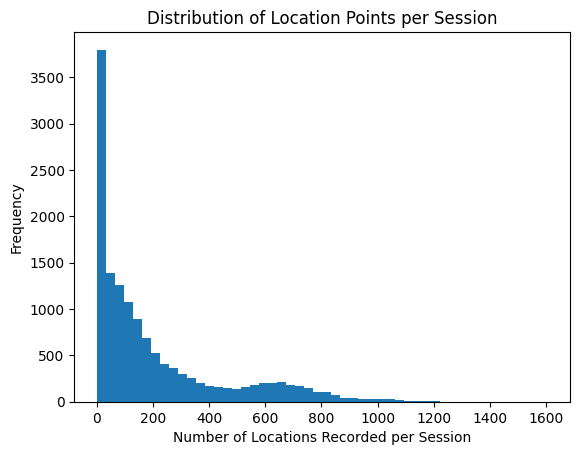

In [31]:
import numpy as np
import matplotlib.pyplot as plt

data = gps_stats["total_rows"].dropna()

plt.figure()
plt.hist(data, bins=50)

plt.xlabel("Number of Locations Recorded per Session")
plt.ylabel("Frequency")
plt.title("Distribution of Location Points per Session")


In [34]:
gps_stats_filtered = gps_stats[
    gps_stats["session_length"].dt.total_seconds() > 0
].copy()

gps_stats_filtered["session_length_hours"] = (
    gps_stats_filtered["session_length"].dt.total_seconds() / 3600
)

gps_stats_filtered["locations_per_hour"] = (
    gps_stats_filtered["total_rows"] /
    gps_stats_filtered["session_length_hours"]
)

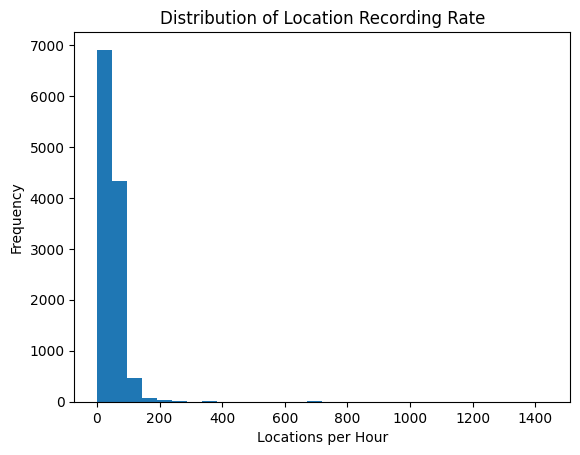

In [36]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(gps_stats_filtered["locations_per_hour"].dropna(), bins=30)
plt.xlabel("Locations per Hour")
plt.ylabel("Frequency")
plt.title("Distribution of Location Recording Rate")
plt.show()


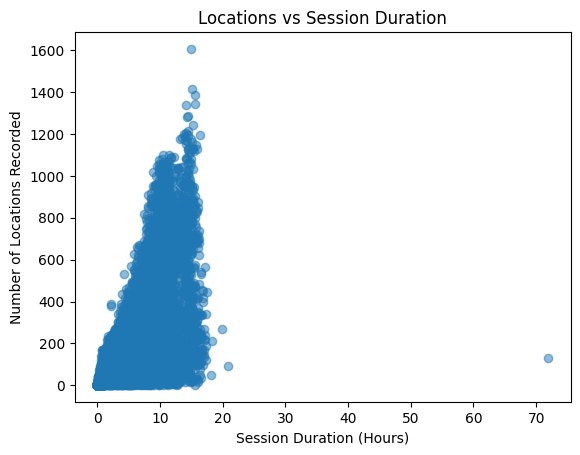

In [37]:
plt.figure()
plt.scatter(gps_stats_filtered["session_length_hours"], gps_stats_filtered["total_rows"], alpha=0.5)
plt.xlabel("Session Duration (Hours)")
plt.ylabel("Number of Locations Recorded")
plt.title("Locations vs Session Duration")
plt.show()


In [38]:
gps_stats_filtered.to_csv("gps_stats_filtered.csv", index=False)

### Time Gap Analysis for Location

In [32]:
import numpy as np
import pandas as pd
from datetime import datetime

# Filter LOCATION events
print(datetime.now(), "Filtering LOCATION events...")
loc = events.loc[
    events["EVENT_TYPE"] == "LOCATION",
    ["SESSION_ID", "LOGGED_AT", "decoded_message"]
].dropna(subset=["LOGGED_AT", "decoded_message"])

loc["LOGGED_AT"] = pd.to_datetime(loc["LOGGED_AT"])

# Latitude and longitude extraction using regex
import pandas as pd

def extract_lat_lon(msg):
    lat = lon = None
    if isinstance(msg, str):
        for line in msg.splitlines():  # handles \n and \r\n
            if line.strip().startswith("latitude:"):
                try:
                    lat = int(line.split(":")[1].strip())
                except:
                    lat = None
            elif line.strip().startswith("longitude:"):
                try:
                    lon = int(line.split(":")[1].strip())
                except:
                    lon = None
    return pd.Series([lat, lon])

# Ensure decoded_message is string
loc["decoded_message"] = loc["decoded_message"].astype(str)
print(datetime.now(), "Starting lat/lon extraction...")
# Apply extraction
loc[["latitude", "longitude"]] = loc["decoded_message"].apply(extract_lat_lon)

# Scale last 7 digits to decimals
loc["latitude"]  = loc["latitude"].astype(float) / 1e7
loc["longitude"] = loc["longitude"].astype(float) / 1e7

print(datetime.now(), "Completed lat/lon extraction.")

# Flag valid GPS coordinates
loc["gps_valid"] = loc["latitude"].between(-90, 90) & loc["longitude"].between(-180, 180)

# Sort by session and time
loc = loc.sort_values(["SESSION_ID", "LOGGED_AT"])

# Compute previous row info per session
loc["prev_time"] = loc.groupby("SESSION_ID")["LOGGED_AT"].shift()
loc["prev_lat"]  = loc.groupby("SESSION_ID")["latitude"].shift()
loc["prev_lon"]  = loc.groupby("SESSION_ID")["longitude"].shift()
loc["prev_decoded_message"] = loc.groupby("SESSION_ID")["decoded_message"].shift()

print(datetime.now(), "starting distance and time difference calculations...")
# Haversine distance (vectorized)
R = 6371000  # Earth radius in meters

lat1 = np.radians(loc["prev_lat"])
lon1 = np.radians(loc["prev_lon"])
lat2 = np.radians(loc["latitude"])
lon2 = np.radians(loc["longitude"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
loc["distance_m"] = 2 * R * np.arcsin(np.sqrt(a))

# Time difference
loc["time_diff_hours"] = (loc["LOGGED_AT"] - loc["prev_time"]).dt.total_seconds() / 3600

# Max time gap per session
idx = loc.groupby("SESSION_ID")["time_diff_hours"].idxmax().dropna()

# Assemble result dataframe
result = loc.loc[idx, [
    "SESSION_ID",
    "prev_time", "LOGGED_AT",
    "prev_lat", "prev_lon",
    "latitude", "longitude",
    "time_diff_hours",
    "distance_m",
    "prev_decoded_message",
    "decoded_message",
    "gps_valid"
]].rename(columns={
    "prev_time": "start_time",
    "LOGGED_AT": "end_time",
    "prev_lat": "start_lat",
    "prev_lon": "start_lon",
    "latitude": "end_lat",
    "longitude": "end_lon",
    "prev_decoded_message": "start_decoded_message",
    "decoded_message": "end_decoded_message"
}).sort_values("time_diff_hours", ascending=False).reset_index(drop=True)


2026-02-16 09:25:13.650139 Filtering LOCATION events...
2026-02-16 09:25:30.631122 Starting lat/lon extraction...
2026-02-16 09:40:19.549543 Completed lat/lon extraction.
2026-02-16 09:40:21.004997 starting distance and time difference calculations...


In [9]:
result.to_csv('/Users/aishanipradhan/Desktop/capstone/longest_location_gaps.csv', index=False)

In [7]:
result

,SESSION_ID,start_time,end_time,start_lat,start_lon,end_lat,end_lon,time_diff_hours,distance_m,start_decoded_message,end_decoded_message
0,5afdee58-91a4-4361-8a2d-7e15c20c40b6,2025-03-12 18:03:55,2025-03-15 04:59:43,60.306580,25.518663,214.748365,214.748365,58.930000,1.060334e+07,longitude: 255186626\nlatitude: 603065796\nalt...,longitude: 2147483647\nlatitude: 2147483647\ne...
1,c5516f0d-a69a-4c9b-a79c-bbe9a2da876b,2025-02-16 13:21:01,2025-02-17 05:00:48,60.306636,25.518713,60.306668,25.518714,15.663056,3.547546e+00,longitude: 255187133\nlatitude: 603066361\nalt...,longitude: 255187143\nlatitude: 603066680\nalt...
2,662878c8-17ba-4094-9b99-a9fb7dfbb398,2025-01-08 05:54:00,2025-01-08 19:37:32,214.748365,214.748365,60.309943,25.525554,13.725556,1.060366e+07,longitude: 2147483647\nlatitude: 2147483647\ne...,longitude: 255255541\nlatitude: 603099433\nalt...
3,69eb7d4c-b716-4778-9215-f4a4e959faa1,2025-03-13 05:42:06,2025-03-13 18:53:04,214.748365,214.748365,60.308483,25.543355,13.182778,1.060337e+07,longitude: 2147483647\nlatitude: 2147483647\n,longitude: 255433553\nlatitude: 603084828\nalt...
4,4bf094fc-c9c7-4fcc-9020-132ade47758b,2025-03-05 06:26:42,2025-03-05 19:36:41,214.748365,214.748365,60.311796,25.525685,13.166389,1.060386e+07,longitude: 2147483647\nlatitude: 2147483647\n,longitude: 255256853\nlatitude: 603117960\nalt...
...,...,...,...,...,...,...,...,...,...,...,...
11845,1afa3ce3-f1cd-4ff4-81b6-6061bbb89d18,2025-02-26 04:57:15,2025-02-26 04:57:25,214.748365,214.748365,60.306608,25.518804,0.002778,1.060334e+07,longitude: 2147483647\nlatitude: 2147483647\n,longitude: 255188043\nlatitude: 603066078\nalt...
11846,075e2abc-5ed0-4078-9f68-e9b0e29a8f3a,2025-02-18 05:01:03,2025-02-18 05:01:12,214.748365,214.748365,60.306640,25.518750,0.002500,1.060335e+07,longitude: 2147483647\nlatitude: 2147483647\n,longitude: 255187500\nlatitude: 603066395\nalt...
11847,b0c6375e-fe35-4450-b06b-880df2357e42,2025-03-02 05:00:35,2025-03-02 05:00:44,214.748365,214.748365,60.306576,25.518627,0.002500,1.060334e+07,longitude: 2147483647\nlatitude: 2147483647\n,longitude: 255186266\nlatitude: 603065763\nalt...
11848,3b38a3fd-1f54-40d6-8395-1bdc8eff811f,2025-03-04 09:46:32,2025-03-04 09:46:37,60.305020,25.503316,60.304782,25.503225,0.001389,2.693596e+01,longitude: 255033156\nlatitude: 603050198\nalt...,longitude: 255032245\nlatitude: 603047818\nalt...


## (Extra EDA - ignore)
Check sessions with more than one recorded date.

In [ ]:

df = (
    events.loc[
        events["SESSION_ID"].isin(bad_sessions.index),
        ["SESSION_ID", "LOGGED_AT_DATE", "LOGGED_AT", "decoded_message"]
    ]
    .dropna(subset=["LOGGED_AT_DATE"])
)

df = df.sort_values(["SESSION_ID", "LOGGED_AT_DATE"])

date_change = (
    df.groupby("SESSION_ID")["LOGGED_AT_DATE"]
      .apply(lambda x: x.ne(x.shift()))
)

rows = []

rows = []

for sid, grp in df.groupby("SESSION_ID", sort=False):
    grp = grp.sort_values("LOGGED_AT_DATE")

    change_pos = grp["LOGGED_AT_DATE"].ne(
        grp["LOGGED_AT_DATE"].shift()
    ).to_numpy().nonzero()[0][1:]  # skip first row

    for pos in change_pos:
        rows.append(grp.iloc[pos - 1])
        rows.append(grp.iloc[pos])

result = (
    pd.DataFrame(rows)
    .sort_values(["SESSION_ID", "LOGGED_AT"])
    .reset_index(drop=True)
)


